# Finnish BERT — Colab Training

Finnish embedding model from scratch:
- **No HuggingFace** — pure PyTorch + Python stdlib
- **BPE tokenizer** (50 K vocab, 03_tokenizer.py)
- **BERT 6L/256H/4A** — 17.6 M parameters (05_model.py)
- **MLM pre-training** with Whole Word Masking (04_dataset.py)
- **fp16 mixed precision**, gradient accumulation × 4 (eff. batch 512)

### Steps in this notebook
1. GPU check
2. Mount Google Drive
3. Clone the repo
4. Install dependencies
5. Create file symlinks
6. Build dataset.pt (BPE tokenise)
7. Train (`06_train.py`)
8. Plot loss curve
9. Embedding sanity check


In [1]:
## Step 1: GPU Check

import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA not found!\n"
        "From Colab menu: Runtime → Change Runtime Type → A100 GPU"
    )

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"GPU  : {gpu_name}")
print(f"VRAM : {vram_gb:.1f} GB")

if "A100" not in gpu_name:
    print(f"\nWarning: Not A100, training will be slower.")
    print(f"  Current GPU : {gpu_name}")
    print("  For A100    : Runtime → Change Runtime Type")
else:
    print("\nA100 GPU ready.")


GPU  : NVIDIA A100-SXM4-40GB
VRAM : 42.4 GB

A100 GPU ready.


In [2]:
## Step 2: Mount Google Drive

from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_ROOT = "/content/drive/MyDrive/Finnish-Embedding"

# Check required files
required_files = {
    f"{DRIVE_ROOT}/data/tokenizer/vocab.json":    "Tokenizer vocab",
    f"{DRIVE_ROOT}/data/tokenizer/merges.txt":    "Tokenizer merge rules",
    f"{DRIVE_ROOT}/data/processed/sentences.txt": "Cleaned corpus",
}

errors = []
for path, desc in required_files.items():
    if not os.path.exists(path):
        errors.append(f"  MISSING  {desc}: {path}")
    else:
        size_mb = os.path.getsize(path) / 1024**2
        print(f"  OK  {desc}  ({size_mb:.1f} MB)")

if errors:
    raise FileNotFoundError(
        "Missing files on Drive:\n" + "\n".join(errors) + "\n\n"
        "Please run the following scripts locally first:\n"
        "  python src/01_data_download.py   → raw data\n"
        "  python src/02_clean.py            → sentences.txt\n"
        "  python src/03_tokenizer.py        → vocab.json + merges.txt\n"
        "Then upload these files to Drive."
    )

# Create checkpoints directory
os.makedirs(f"{DRIVE_ROOT}/checkpoints", exist_ok=True)
print(f"\nDrive ready: {DRIVE_ROOT}")


Mounted at /content/drive
  OK  Tokenizer vocab  (1.1 MB)
  OK  Tokenizer merge rules  (0.6 MB)
  OK  Cleaned corpus  (912.5 MB)

Drive ready: /content/drive/MyDrive/Finnish-Embedding


In [3]:
## Step 3: Clone the Repo

import os

REPO_URL = "https://github.com/tyerdogan/finnish-embedding"

if not os.path.exists("/content/finnish-embedding"):
    print(f"Cloning: {REPO_URL}")
    !git clone {REPO_URL}
else:
    print("Repo already exists, skipping clone.")

%cd /content/finnish-embedding
print(f"Working directory: {os.getcwd()}")


Cloning: https://github.com/tyerdogan/finnish-embedding
Cloning into 'finnish-embedding'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 18 (delta 2), reused 18 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 50.10 KiB | 2.64 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/finnish-embedding
Working directory: /content/finnish-embedding


In [4]:
## Step 4: Install Dependencies

!pip install tqdm -q

# No dependencies beyond PyTorch and Python stdlib.
# tqdm may already be installed in Colab — -q runs silently.

import torch, tqdm
print(f"PyTorch : {torch.__version__}")
print(f"tqdm    : {tqdm.__version__}")
print("Dependencies ready.")


PyTorch : 2.10.0+cu128
tqdm    : 4.67.3
Dependencies ready.


In [6]:
## Step 5: Create File Symlinks

import os

DRIVE_ROOT = "/content/drive/MyDrive/Finnish-Embedding"

# 1. Create local directory structure
for d in ("data/tokenizer", "data/processed", "checkpoints"):
    os.makedirs(d, exist_ok=True)
print("Directory structure ready.")

def safe_symlink(src, dst):
    """Creates a symlink; silently skips if the target already exists."""
    if os.path.exists(dst) or os.path.islink(dst):
        size_mb = os.path.getsize(dst) / 1024**2 if os.path.exists(dst) else 0
        print(f"  -- Already exists : {dst}  ({size_mb:.0f} MB)")
        return
    os.symlink(src, dst)
    size_mb = os.path.getsize(src) / 1024**2 if os.path.exists(src) else 0
    print(f"  OK Linked         : {dst}  ({size_mb:.0f} MB)")

# 2. Tokenizer files
print("\nTokenizer:")
safe_symlink(f"{DRIVE_ROOT}/data/tokenizer/vocab.json",  "data/tokenizer/vocab.json")
safe_symlink(f"{DRIVE_ROOT}/data/tokenizer/merges.txt",  "data/tokenizer/merges.txt")

# 3. Corpus
print("\nCorpus:")
safe_symlink(f"{DRIVE_ROOT}/data/processed/sentences.txt", "data/processed/sentences.txt")

# 4. Link previous checkpoints (for resuming)
print("\nCheckpoints:")
drive_ckpt_dir = f"{DRIVE_ROOT}/checkpoints"
if os.path.isdir(drive_ckpt_dir):
    ckpts = sorted(
        f for f in os.listdir(drive_ckpt_dir)
        if f.startswith("checkpoint_step") and f.endswith(".pt")
    )
    if ckpts:
        for ckpt in ckpts:
            safe_symlink(f"{drive_ckpt_dir}/{ckpt}", f"checkpoints/{ckpt}")
        print(f"  {len(ckpts)} checkpoint(s) linked — training will resume from the last one.")
    else:
        print("  No checkpoints on Drive — training will start from scratch.")
else:
    print("  Checkpoints directory does not exist yet.")

print("\nFile setup complete.")


Directory structure ready.

Tokenizer:
  -- Already exists : data/tokenizer/vocab.json  (1 MB)
  -- Already exists : data/tokenizer/merges.txt  (1 MB)

Corpus:
  -- Already exists : data/processed/sentences.txt  (912 MB)

Checkpoints:
  -- Already exists : checkpoints/checkpoint_step002000.pt  (202 MB)
  -- Already exists : checkpoints/checkpoint_step004000.pt  (202 MB)
  -- Already exists : checkpoints/checkpoint_step006000.pt  (202 MB)
  -- Already exists : checkpoints/checkpoint_step008000.pt  (202 MB)
  -- Already exists : checkpoints/checkpoint_step010000.pt  (202 MB)
  -- Already exists : checkpoints/checkpoint_step012000.pt  (202 MB)
  6 checkpoint(s) linked — training will resume from the last one.

File setup complete.


In [7]:
## Step 6: Build dataset.pt

# 04_dataset.preprocess_and_save:
#   BPE-tokenises 2M paragraphs and saves them as a LongTensor (~2 minutes).
#   On subsequent Colab sessions it is linked from Drive — not rebuilt each time.

import os, shutil

DRIVE_ROOT = "/content/drive/MyDrive/Finnish-Embedding"
LOCAL_PT   = "data/processed/dataset.pt"
DRIVE_PT   = f"{DRIVE_ROOT}/data/processed/dataset.pt"

if os.path.exists(LOCAL_PT):
    size_mb = os.path.getsize(LOCAL_PT) / 1024**2
    print(f"dataset.pt exists ({size_mb:.0f} MB), skipping.")

elif os.path.exists(DRIVE_PT):
    # Generated in a previous session — just link it
    os.symlink(DRIVE_PT, LOCAL_PT)
    size_mb = os.path.getsize(LOCAL_PT) / 1024**2
    print(f"dataset.pt linked from Drive ({size_mb:.0f} MB).")

else:
    print("Building dataset.pt (~2 minutes)...")
    print("BPE-tokenising 2M paragraphs and saving as LongTensor.\n")
    !python src/04_dataset.py --build-only

    if os.path.exists(LOCAL_PT):
        # Copy to Drive so the next session can load it quickly
        os.makedirs(f"{DRIVE_ROOT}/data/processed", exist_ok=True)
        shutil.copy(LOCAL_PT, DRIVE_PT)
        size_mb = os.path.getsize(LOCAL_PT) / 1024**2
        print(f"\ndataset.pt built and copied to Drive ({size_mb:.0f} MB).")
    else:
        raise RuntimeError("dataset.pt was not produced. Check 04_dataset.py output.")


dataset.pt linked from Drive (3906 MB).


In [8]:
## Step 7: Start Training

# 06_train.py manages the full training loop:
#   - Resumes from the latest checkpoint_step*.pt in checkpoints/ if one exists
#   - Saves a checkpoint every 2 000 steps (also written to Drive)
#   - Logs loss / ppl / lr / ETA every 100 steps
#   - Total ~30 minutes  (A100, 45 000 steps, fp16, eff. batch 512)

!python src/06_train.py


TrainingConfig
──────────────────────────────────────────────────
  dataset_path                   = data/processed/dataset.pt
  tokenizer_dir                  = data/tokenizer
  checkpoint_dir                 = checkpoints
  drive_checkpoint_dir           = /content/drive/MyDrive/Finnish-Embedding/checkpoints
  batch_size                     = 128
  grad_accum_steps               = 4
  max_steps                      = 45000
  warmup_ratio                   = 0.1
  lr                             = 0.0001
  weight_decay                   = 0.01
  beta1                          = 0.9
  beta2                          = 0.999
  eps                            = 1e-08
  max_grad_norm                  = 1.0
  checkpoint_every               = 2000
  log_every                      = 100
  use_drive                      = True
  use_fp16                       = True
  seed                           = 42
──────────────────────────────────────────────────
Drive already mounted at /content/drive
De

Checkpoint : checkpoints/checkpoint_step045000.pt
Total steps  : 45,000
Final loss   : 5.4122
Final PPL    : 224.1

Plot saved: /content/drive/MyDrive/Finnish-Embedding/loss_curve.png


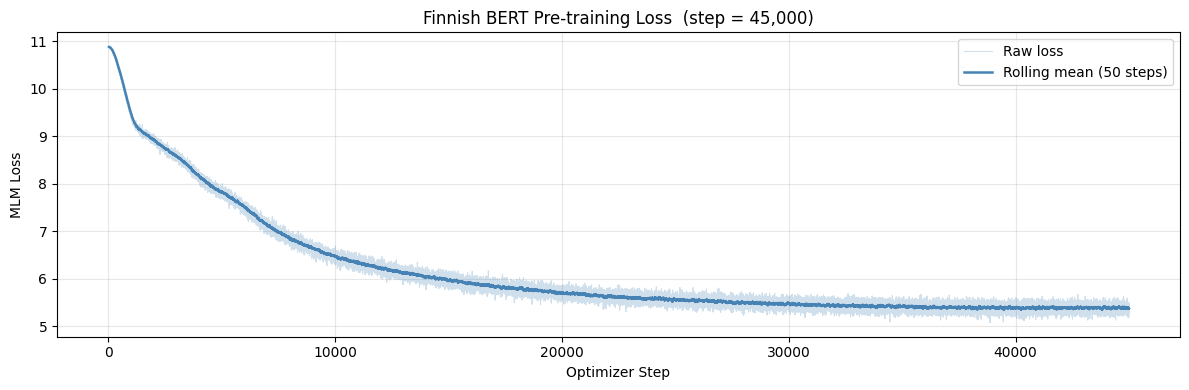

In [9]:
## Step 8: Plot Loss Curve

import glob, math, shutil, torch
import matplotlib.pyplot as plt

DRIVE_ROOT = "/content/drive/MyDrive/Finnish-Embedding"

checkpoints = sorted(glob.glob("checkpoints/checkpoint_step*.pt"))
if not checkpoints:
    print("No checkpoints found. Complete Step 7 first.")
else:
    latest = checkpoints[-1]
    print(f"Checkpoint : {latest}")

    ckpt         = torch.load(latest, map_location="cpu", weights_only=False)
    loss_history = ckpt["loss_history"]
    total_steps  = ckpt["step"]

    final_loss = loss_history[-1]
    final_ppl  = math.exp(min(final_loss, 20))
    print(f"Total steps  : {total_steps:,}")
    print(f"Final loss   : {final_loss:.4f}")
    print(f"Final PPL    : {final_ppl:.1f}")

    fig, ax = plt.subplots(figsize=(12, 4))
    steps   = list(range(1, len(loss_history) + 1))

    # Raw loss (faint)
    ax.plot(steps, loss_history,
            alpha=0.25, color="steelblue", linewidth=0.8, label="Raw loss")

    # Rolling mean
    W = 50
    if len(loss_history) >= W:
        rolling = [sum(loss_history[i:i+W]) / W
                   for i in range(len(loss_history) - W + 1)]
        ax.plot(range(W, len(loss_history) + 1), rolling,
                color="steelblue", linewidth=1.8,
                label=f"Rolling mean ({W} steps)")

    ax.set_xlabel("Optimizer Step")
    ax.set_ylabel("MLM Loss")
    ax.set_title(f"Finnish BERT Pre-training Loss  (step = {total_steps:,})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig("loss_curve.png", dpi=150)
    shutil.copy("loss_curve.png", f"{DRIVE_ROOT}/loss_curve.png")
    print(f"\nPlot saved: {DRIVE_ROOT}/loss_curve.png")
    plt.show()


In [10]:
## Step 9: Embedding Sanity Check

# Encode 5 Finnish sentences and compute a cosine-similarity matrix.
# Semantically similar sentences should be close to each other.

import importlib.util, glob, math, torch

def load_mod(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

tok_mod   = load_mod("tok",   "src/03_tokenizer.py")
model_mod = load_mod("model", "src/05_model.py")

# ── Tokenizer ────────────────────────────────────────────────────────────────
vocab, merges = tok_mod.load_tokenizer("data/tokenizer")
print(f"Tokenizer : {len(vocab):,} tokens")

# ── Model ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg    = model_mod.BertConfig()
model  = model_mod.BertForMLM(cfg).to(device)

checkpoints = sorted(glob.glob("checkpoints/checkpoint_step*.pt"))
if checkpoints:
    ckpt = torch.load(checkpoints[-1], map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Model     : {checkpoints[-1]}")
else:
    print("No checkpoint found — using randomly initialised model (meaningless results expected).")

model.eval()

# ── Test sentences (Finnish) ──────────────────────────────────────────────────
sentences = [
    ("Pet / moving",    "Koira juoksi puistossa."),    # Dog ran in the park
    ("Pet / resting",   "Kissa nukkui sohvalla."),     # Cat slept on the sofa
    ("Vehicle / moving","Auto ajoi nopeasti tiellä."), # Car drove fast on the road
    ("Human / reading", "Hän luki kirjaa hiljaa."),    # She read a book quietly
    ("Child / playing", "Lapsi leikki ulkona."),       # Child played outside
]

# ── Encode + embed ────────────────────────────────────────────────────────────
MAX_LEN = cfg.max_seq_length
CLS, SEP, PAD = vocab["[CLS]"], vocab["[SEP]"], vocab["[PAD]"]

def embed(text):
    tids  = tok_mod.encode(text, merges, vocab)[:MAX_LEN - 2]
    seq   = [CLS] + tids + [SEP]
    n_pad = MAX_LEN - len(seq)
    mask  = [1] * len(seq) + [0] * n_pad
    seq   = seq + [PAD] * n_pad
    ids_t  = torch.tensor(seq,  dtype=torch.long).unsqueeze(0).to(device)
    mask_t = torch.tensor(mask, dtype=torch.long).unsqueeze(0).to(device)
    return model_mod.get_sentence_embedding(model, ids_t, mask_t).squeeze(0)

embeddings = torch.stack([embed(s) for _, s in sentences])  # (5, H)

# ── Cosine similarity (embeddings are L2-normalised → cosine = dot product) ──
sim = torch.mm(embeddings, embeddings.T).cpu()

# ── Table ─────────────────────────────────────────────────────────────────────
labels = [f"S{i+1}" for i in range(len(sentences))]
LW = 22
print(f"\nCosine Similarity Matrix")
print("-" * (LW + 8 * len(sentences)))
print(f"{'':>{LW}}" + "".join(f"{l:>8}" for l in labels))
for i, (tag, sent) in enumerate(sentences):
    row = "".join(f"{sim[i, j]:8.3f}" for j in range(len(sentences)))
    print(f"{tag:<{LW}}{row}")

print("\nNote: 1.000 = self, higher = more semantically similar.")
print("      Random values without a checkpoint are expected.")


Tokenizer : 50,000 tokens
Model     : checkpoints/checkpoint_step045000.pt

Cosine Similarity Matrix
--------------------------------------------------------------
                            S1      S2      S3      S4      S5
Pet / moving             1.000   0.882   0.858   0.812   0.833
Pet / resting            0.882   1.000   0.808   0.828   0.857
Vehicle / moving         0.858   0.808   1.000   0.788   0.787
Human / reading          0.812   0.828   0.788   1.000   0.788
Child / playing          0.833   0.857   0.787   0.788   1.000

Note: 1.000 = self, higher = more semantically similar.
      Random values without a checkpoint are expected.
